In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
# Dosya yolu
df = pd.read_excel("C:\\Users\zehra\\OneDrive\Masaüstü\dataset2025.xlsx"){
 "cells": [
  {
   "cell_type": "code",
   "execution_count": 1,
   "id": "02a9b22c-01fd-4f76-8afa-ade6224ebe30",
   "metadata": {},
   "outputs": [],
   "source": [
    "import pandas as pd\n",
    "import numpy as np\n",
    "import matplotlib.pyplot as plt\n",
    "import seaborn as sns\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 5,
   "id": "7c75d16b-b65d-46f4-b391-0e726b74ae71",
   "metadata": {},
   "outputs": [],
   "source": [
    "# Dosya yolu\n",
    "df = pd.read_excel(\"C:\\\\Users\\zehra\\\\OneDrive\\Masaüstü\\dataset2025.xlsx\")\n",
    "\n",
    "# Tarih dönüşümü\n",
    "df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 6,
   "id": "7a90d455-b562-4e64-a122-ddabafd48c46",
   "metadata": {},
   "outputs": [],
   "source": [
    "# Analiz \n",
    "analysis_date = df['PurchaseDate'].max() + pd.Timedelta(days=1)\n",
    "\n",
    "# RFM hesaplama\n",
    "rfm = df.groupby('CustomerID').agg({\n",
    "    'PurchaseDate': lambda x: (analysis_date - x.max()).days,\n",
    "    'CustomerID': 'count',\n",
    "    'PurchaseAmount': 'sum'\n",
    "}).rename(columns={\n",
    "    'PurchaseDate': 'Recency',\n",
    "    'CustomerID': 'Frequency',\n",
    "    'PurchaseAmount': 'Monetary'\n",
    "})\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 7,
   "id": "6fb43dd2-8f82-426d-ab46-8098bd0c659e",
   "metadata": {},
   "outputs": [],
   "source": [
    "# Her bir metriği 1 (kötü) - 5 (iyi) arasında puanla\n",
    "rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])\n",
    "rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])\n",
    "rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])\n",
    "\n",
    "# RFM skorunu oluştur\n",
    "rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 8,
   "id": "60fdea5d-20f1-40b5-9adb-a913aaaf8a3f",
   "metadata": {},
   "outputs": [],
   "source": [
    "# segmentleme (isteğe göre değiştirilebilir)\n",
    "def segment(x):\n",
    "    if x['RFM_Score'] == '555':\n",
    "        return 'VIP Customers'\n",
    "    elif x['R_Score'] == '5':\n",
    "        return 'Loyal Customers'\n",
    "    elif x['R_Score'] == '1':\n",
    "        return 'At Risk'\n",
    "    elif x['F_Score'] == '1':\n",
    "        return 'Need Attention'\n",
    "    else:\n",
    "        return 'Others'\n",
    "\n",
    "rfm['Segment'] = rfm.apply(segment, axis=1)\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 9,
   "id": "cd11b2a0-1846-4b0f-b949-502583878077",
   "metadata": {},
   "outputs": [
    {
     "name": "stderr",
     "output_type": "stream",
     "text": [
      "C:\\Users\\zehra\\AppData\\Local\\Temp\\ipykernel_3112\\1562594758.py:2: FutureWarning: \n",
      "\n",
      "Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.\n",
      "\n",
      "  sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='viridis')\n"
     ]
    },
    {
     "data": {
      "image/png": "...",
      "text/plain": [
       "<Figure size 1000x600 with 1 Axes>"
      ]
     },
     "metadata": {},
     "output_type": "display_data"
    }
   ],
   "source": [
    "plt.figure(figsize=(10, 6))\n",
    "sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='viridis')\n",
    "plt.title(\"Customer Segment Distribution\", fontsize=14)\n",
    "plt.xlabel(\"Segment\")\n",
    "plt.ylabel(\"Number of Customers\")\n",
    "plt.xticks(rotation=45)\n",
    "plt.tight_layout()\n",
    "plt.show()\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 13,
   "id": "125e0746-ec89-4023-a3aa-0ec22f4b397a",
   "metadata": {},
   "outputs": [],
   "source": [
    "# RFM skorlarını birleştir\n",
    "rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str)\n",
    "\n",
    "# Segment kuralları (daha detaylı)\n",
    "segment_map = {\n",
    "    r'[5][5]': 'VIP Customers',\n",
    "    r'[4-5][3-5]': 'Loyal Customers',\n",
    "    r'[3-4][4-5]': 'Potential Loyalists',\n",
    "    r'[5][1-2]': 'New Customers',\n",
    "    r'[3-4][1-3]': 'Needs Attention',\n",
    "    r'[1-2][4-5]': 'At Risk',\n",
    "    r'[1-2][1-2]': 'Hibernating'\n",
    "}\n",
    "\n",
    "# Regex ile eşleştirerek segment ata\n",
    "import re\n",
    "\n",
    "def get_segment(score):\n",
    "    for pattern, segment in segment_map.items():\n",
    "        if re.match(pattern, score):\n",
    "            return segment\n",
    "    return 'Others'\n",
    "\n",
    "rfm['Segment'] = rfm['RFM_Score'].apply(get_segment)\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 14,
   "id": "779141f0-ad12-4917-8baf-3a8e17534d0b",
   "metadata": {
    "scrolled": true
   },
   "outputs": [
    {
     "name": "stderr",
     "output_type": "stream",
     "text": [
      "C:\\Users\\zehra\\AppData\\Local\\Temp\\ipykernel_3112\\3852615847.py:2: FutureWarning: \n",
      "\n",
      "Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.\n",
      "\n",
      "  sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='cubehelix')\n"
     ]
    },
    {
     "data": {
      "image/png": "...",
      "text/plain": [
       "<Figure size 1000x600 with 1 Axes>"
      ]
     },
     "metadata": {},
     "output_type": "display_data"
    }
   ],
   "source": [
    "plt.figure(figsize=(10, 6))\n",
    "sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='cubehelix')\n",
    "plt.title(\"RFM Müşteri Segment Dağılımı\", fontsize=14)\n",
    "plt.xlabel(\"Segment\")\n",
    "plt.ylabel(\"Müşteri Sayısı\")\n",
    "plt.xticks(rotation=45)\n",
    "plt.tight_layout()\n",
    "plt.show()\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 15,
   "id": "b6544697-0d16-4e5b-b388-b58ccc5e174d",
   "metadata": {},
   "outputs": [
    {
     "name": "stderr",
     "output_type": "stream",
     "text": [
      "C:\\Users\\zehra\\AppData\\Local\\Temp\\ipykernel_3112\\694044206.py:3: FutureWarning: \n",
      "\n",
      "Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.\n",
      "\n",
      "  sns.barplot(x=segment_monetary.index, y=segment_monetary.values, palette='Blues_d')\n"
     ]
    },
    {
     "data": {
      "image/png": "...",
      "text/plain": [
       "<Figure size 1000x600 with 1 Axes>"
      ]
     },
     "metadata": {},
     "output_type": "display_data"
    }
   ],
   "source": [
    "plt.figure(figsize=(10, 6))\n",
    "segment_monetary = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)\n",
    "sns.barplot(x=segment_monetary.index, y=segment_monetary.values, palette='Blues_d')\n",
    "plt.title(\"Segmentlere Göre Ortalama Harcama (Monetary)\", fontsize=14)\n",
    "plt.xlabel(\"Segment\")\n",
    "plt.ylabel(\"Ortalama Harcama (₺)\")\n",
    "plt.xticks(rotation=45)\n",
    "plt.tight_layout()\n",
    "plt.show()\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 16,
   "id": "29bea05c-c4f4-4b4d-b7c6-db8be4945519",
   "metadata": {},
   "outputs": [],
   "source": [
    "from sklearn.preprocessing import StandardScaler\n",
    "from sklearn.cluster import DBSCAN\n",
    "import seaborn as sns\n",
    "import matplotlib.pyplot as plt\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 17,
   "id": "3993678e-1933-4f54-b354-fe1aa88aa282",
   "metadata": {},
   "outputs": [],
   "source": [
    "# Eğer rfm tablosu yoksa önce onu oluştur\n",
    "# Burada Recency, Frequency, Monetary zaten hesaplanmış olmalı\n",
    "\n",
    "# Ölçekleme işlemi (DBSCAN mesafeye duyarlıdır!)\n",
    "scaler = StandardScaler()\n",
    "rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 18,
   "id": "ebd2671d-1bb4-40d4-9b50-e4a20375f516",
   "metadata": {},
   "outputs": [],
   "source": [
    "# DBSCAN modeli\n",
    "db = DBSCAN(eps=0.8, min_samples=5)\n",
    "rfm['DBSCAN_Cluster'] = db.fit_predict(rfm_scaled)\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 19,
   "id": "c3618495-739f-4869-b624-16f6da1e1f42",
   "metadata": {},
   "outputs": [
    {
     "data": {
      "image/png": "...",
      "text/plain": [
       "<Figure size 800x600 with 1 Axes>"
      ]
     },
     "metadata": {},
     "output_type": "display_data"
    }
   ],
   "source": [
    "plt.figure(figsize=(8,6))\n",
    "sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='DBSCAN_Cluster', palette='tab10')\n",
    "plt.title('DBSCAN Clustering (Recency vs Monetary)', fontsize=14)\n",
    "plt.legend(title='Cluster')\n",
    "plt.show()\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 20,
   "id": "1f6fad1d-ac09-4815-b802-22f6d48739c7",
   "metadata": {},
   "outputs": [
    {
     "data": {
      "text/plain": [
       "DBSCAN_Cluster\n",
       " 2    4826\n",
       " 1    3993\n",
       " 0    1633\n",
       " 3     458\n",
       " 4      75\n",
       "-1      14\n",
       "Name: count, dtype: int64"
      ]
     },
     "execution_count": 20,
     "metadata": {},
     "output_type": "execute_result"
    }
   ],
   "source": [
    "rfm['DBSCAN_Cluster'].value_counts()\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 21,
   "id": "781fbbf4-a4b6-46de-a913-5e62a2ae1ea7",
   "metadata": {},
   "outputs": [],
   "source": [
    "import pandas as pd\n",
    "import matplotlib.pyplot as plt\n",
    "import seaborn as sns\n",
    "from sklearn.preprocessing import StandardScaler\n",
    "from sklearn.cluster import KMeans\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 23,
   "id": "851a604e-9762-4472-ad88-e27d114fa7f3",
   "metadata": {},
   "outputs": [],
   "source": [
    "df = pd.read_excel(\"C:\\\\Users\\zehra\\OneDrive\\\\Masaüstü\\dataset2025.xlsx\")\n",
    "df['OrderDate'] = pd.to_datetime(df['PurchaseDate'])  # Tarih sütunu\n",
    "\n",
    "# En son alışveriş tarihi varsayılan olarak en güncel tarih alınır\n",
    "snapshot_date = df['PurchaseDate'].max() + pd.Timedelta(days=1)\n",
    "\n",
    "# RFM hesaplama\n",
    "rfm = df.groupby('CustomerID').agg({\n",
    "    'OrderDate': lambda x: (snapshot_date - x.max()).days,   # Recency\n",
    "    'OrderID': 'nunique',                                     # Frequency\n",
    "    'PurchaseAmount': 'sum'                                   # Monetary\n",
    "}).reset_index()\n",
    "\n",
    "rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 24,
   "id": "79d57f54-a7cf-4328-8e4c-9ba746600f1f",
   "metadata": {},
   "outputs": [],
   "source": [
    "scaler = StandardScaler()\n",
    "rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 25,
   "id": "5dcef34c-af31-4489-82ae-b9d0e29c51f9",
   "metadata": {},
   "outputs": [
    {
     "name": "stderr",
     "output_type": "stream",
     "text": [
      "C:\\Users\\zehra\\anaconda3\\Lib\\site-packages\\joblib\\externals\\loky\\backend\\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:\n",
      "[WinError 2] Sistem belirtilen dosyayı bulamıyor\n",
      "Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.\n",
      "  warnings.warn(\n",
      "  File \"C:\\Users\\zehra\\anaconda3\\Lib\\site-packages\\joblib\\externals\\loky\\backend\\context.py\", line 257, in _count_physical_cores\n",
      "    cpu_info = subprocess.run(\n",
      "        \"wmic CPU Get NumberOfCores /Format:csv\".split(),\n",
      "        capture_output=True,\n",
      "        text=True,\n",
      "    )\n",
      "  File \"C:\\Users\\zehra\\anaconda3\\Lib\\subprocess.py\", line 554, in run\n",
      "    with Popen(*popenargs, **kwargs) as process:\n",
      "         ~~~~~^^^^^^^^^^^^^^^^^^^^^^\n",
      "  File \"C:\\Users\\zehra\\anaconda3\\Lib\\subprocess.py\", line 1039, in __init__\n",
      "    self._execute_child(args, executable, preexec_fn, close_fds,\n",
      "    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n",
      "                        pass_fds, cwd, env,\n",
      "                        ^^^^^^^^^^^^^^^^^^^\n",
      "    ...<5 lines>...\n",
      "                        gid, gids, uid, umask,\n",
      "                        ^^^^^^^^^^^^^^^^^^^^^^\n",
      "                        start_new_session, process_group)\n",
      "                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n",
      "  File \"C:\\Users\\zehra\\anaconda3\\Lib\\subprocess.py\", line 1554, in _execute_child\n",
      "    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,\n",
      "                       ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^\n",
      "                             # no special security\n",
      "                             ^^^^^^^^^^^^^^^^^^^^^\n",
      "    ...<4 lines>...\n",
      "                             cwd,\n",
      "                             ^^^^\n",
      "                             startupinfo)\n",
      "                             ^^^^^^^^^^^^\n"
     ]
    },
    {
     "data": {
      "image/png": "...",
      "text/plain": [
       "<Figure size 800x500 with 1 Axes>"
      ]
     },
     "metadata": {},
     "output_type": "display_data"
    }
   ],
   "source": [
    "sse = []\n",
    "K_range = range(1, 11)\n",
    "\n",
    "for k in K_range:\n",
    "    kmeans = KMeans(n_clusters=k, random_state=42)\n",
    "    kmeans.fit(rfm_scaled)\n",
    "    sse.append(kmeans.inertia_)\n",
    "\n",
    "plt.figure(figsize=(8,5))\n",
    "plt.plot(K_range, sse, marker='o')\n",
    "plt.xlabel(\"Number of Clusters (K)\")\n",
    "plt.ylabel(\"SSE (Sum of Squared Errors)\")\n",
    "plt.title(\"Elbow Method for Optimal K\")\n",
    "plt.grid(True)\n",
    "plt.show()\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 27,
   "id": "859aefb8-e59b-4e36-af3c-9e014f6b3523",
   "metadata": {},
   "outputs": [],
   "source": [
    "import pandas as pd\n",
    "import matplotlib.pyplot as plt\n",
    "import seaborn as sns\n",
    "from sklearn.preprocessing import StandardScaler\n",
    "from scipy.cluster.hierarchy import linkage, dendrogram, fcluster\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 28,
   "id": "d223ab8e-0410-43d5-a0ff-c18f938a6dbb",
   "metadata": {},
   "outputs": [
    {
     "data": {
      "image/png": "...",
      "text/plain": [
       "<Figure size 1200x600 with 1 Axes>"
      ]
     },
     "metadata": {},
     "output_type": "display_data"
    }
   ],
   "source": [
    "plt.figure(figsize=(12, 6))\n",
    "linkage_matrix = linkage(rfm_scaled, method='ward')\n",
    "dendrogram(linkage_matrix, truncate_mode='lastp', p=30)\n",
    "plt.title('Customer Dendrogram (Ward Linkage)')\n",
    "plt.xlabel('Customer Index')\n",
    "plt.ylabel('Distance')\n",
    "plt.show()\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 42,
   "id": "01c05d32-f75b-4589-8db6-b0a760bf6e5f",
   "metadata": {},
   "outputs": [],
   "source": [
    "import pandas as pd\n",
    "import matplotlib.pyplot as plt\n",
    "import seaborn as sns\n",
    "from datetime import datetime\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 43,
   "id": "1083a0b3-3632-4d46-9d9c-b155e378cdca",
   "metadata": {},
   "outputs": [],
   "source": [
    "# Örnek olarak 'PurchaseDate' kolonu olduğunu varsayıyoruz\n",
    "df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 44,
   "id": "572ed7b3-edc4-49bb-a310-3bba0291a8c7",
   "metadata": {},
   "outputs": [],
   "source": [
    "# Her müşteri için en son alışveriş tarihi\n",
    "last_purchase = df.groupby('CustomerID')['PurchaseDate'].max().reset_index()\n",
    "last_purchase.columns = ['CustomerID', 'LastPurchaseDate']\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 45,
   "id": "291f61e0-fd65-494c-a774-f928bcab5ad5",
   "metadata": {},
   "outputs": [],
   "source": [
    "# Bugünün tarihini manuel olarak belirle (veri setine göre örnek: 1 Temmuz 2025)\n",
    "today = pd.to_datetime('2025-07-01')\n",
    "\n",
    "# Recency (Son alışverişten bu yana geçen gün sayısı)\n",
    "last_purchase['Recency'] = (today - last_purchase['LastPurchaseDate']).dt.days\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 46,
   "id": "82e34631-c121-481f-9434-9377e39f62d1",
   "metadata": {},
   "outputs": [],
   "source": [
    "# Recency > 60 gün olanları churn olarak kabul edelim\n",
    "last_purchase['ChurnStatus'] = last_purchase['Recency'].apply(lambda x: 'Churn' if x > 60 else 'Active')\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 47,
   "id": "820a6d78-dad3-4a5a-a69d-cb482f51c24f",
   "metadata": {},
   "outputs": [
    {
     "name": "stderr",
     "output_type": "stream",
     "text": [
      "C:\\Users\\zehra\\AppData\\Local\\Temp\\ipykernel_3112\\2590337795.py:3: FutureWarning: \n",
      "\n",
      "Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.\n",
      "\n",
      "  sns.countplot(data=last_purchase, x='ChurnStatus', palette='Set2')\n"
     ]
    },
    {
     "data": {
      "image/png": "...",
      "text/plain": [
       "<Figure size 600x400 with 1 Axes>"
      ]
     },
     "metadata": {},
     "output_type": "display_data"
    }
   ],
   "source": [
    "# Churn vs Active oran grafiği\n",
    "plt.figure(figsize=(6, 4))\n",
    "sns.countplot(data=last_purchase, x='ChurnStatus', palette='Set2')\n",
    "plt.title('Churn Durumu: Aktif vs Terk Eden Müşteriler')\n",
    "plt.xlabel('Durum')\n",
    "plt.ylabel('Müşteri Sayısı')\n",
    "plt.show()\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 48,
   "id": "5531dc4b-4b00-4a3d-a816-91ffd09e4ed9",
   "metadata": {},
   "outputs": [
    {
     "data": {
      "image/png": "...",
      "text/plain": [
       "<Figure size 800x500 with 1 Axes>"
      ]
     },
     "metadata": {},
     "output_type": "display_data"
    }
   ],
   "source": [
    "plt.figure(figsize=(8, 5))\n",
    "sns.histplot(data=last_purchase, x='Recency', bins=30, kde=True, color='skyblue')\n",
    "plt.axvline(60, color='red', linestyle='--', label='Churn Threshold (60 gün)')\n",
    "plt.title('Recency Dağılımı')\n",
    "plt.xlabel('Gün')\n",
    "plt.ylabel('Müşteri Sayısı')\n",
    "plt.legend()\n",
    "plt.show()\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 49,
   "id": "debee989-9a70-48ed-849c-8083d7c8fd7b",
   "metadata": {},
   "outputs": [],
   "source": [
    "# Tarih kolonu datetime formatına çevrilmeli\n",
    "df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 50,
   "id": "f7a9ec12-0a56-4681-822e-835bc88f19f2",
   "metadata": {},
   "outputs": [],
   "source": [
    "# Müşteri bazında temel istatistikler\n",
    "clv_df = df.groupby('CustomerID').agg({\n",
    "    'PurchaseAmount': ['sum', 'count'],\n",
    "    'PurchaseDate': ['min', 'max']\n",
    "}).reset_index()\n",
    "\n",
    "# Kolon isimlerini sadeleştir\n",
    "clv_df.columns = ['CustomerID', 'TotalRevenue', 'TotalTransactions', 'FirstPurchaseDate', 'LastPurchaseDate']\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 51,
   "id": "e8b6bdb2-8265-4ad7-a33c-bd11f8f41e2f",
   "metadata": {},
   "outputs": [],
   "source": [
    "clv_df['AverageOrderValue'] = clv_df['TotalRevenue'] / clv_df['TotalTransactions']\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 52,
   "id": "ada4cb13-7a60-4398-8488-2912adf8c564",
   "metadata": {},
   "outputs": [],
   "source": [
    "clv_df['CustomerLifespan'] = (clv_df['LastPurchaseDate'] - clv_df['FirstPurchaseDate']).dt.days + 1\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 53,
   "id": "7fa9de7d-a928-421e-96fa-e9665206de63",
   "metadata": {},
   "outputs": [],
   "source": [
    "clv_df['PurchaseFrequency'] = clv_df['TotalTransactions'] / clv_df['CustomerLifespan']\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 54,
   "id": "46910571-9c45-4aa1-af7d-c96d9a26e58e",
   "metadata": {},
   "outputs": [],
   "source": [
    "clv_df['CLV'] = clv_df['AverageOrderValue'] * clv_df['PurchaseFrequency'] * clv_df['CustomerLifespan']\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 55,
   "id": "f0a73068-b1de-406e-b042-bac7d0041b06",
   "metadata": {},
   "outputs": [
    {
     "data": {
      "image/png": "...",
      "text/plain": [
       "<Figure size 800x500 with 1 Axes>"
      ]
     },
     "metadata": {},
     "output_type": "display_data"
    }
   ],
   "source": [
    "import matplotlib.pyplot as plt\n",
    "import seaborn as sns\n",
    "\n",
    "plt.figure(figsize=(8,5))\n",
    "sns.histplot(clv_df['CLV'], bins=50, kde=True, color='green')\n",
    "plt.title('CLV Dağılımı')\n",
    "plt.xlabel('Customer Lifetime Value')\n",
    "plt.ylabel('Müşteri Sayısı')\n",
    "plt.show()\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 56,
   "id": "a2a1fc89-79f0-4781-8e8a-53923ec23c2d",
   "metadata": {},
   "outputs": [
    {
     "name": "stdout",
     "output_type": "stream",
     "text": [
      "       CustomerID      CLV\n",
      "6103     60392566  5696.77\n",
      "5148     52670749  5626.95\n",
      "8114     76576487  5407.22\n",
      "10160    93390743  5316.35\n",
      "1619     23656579  5268.49\n",
      "1126     19465193  4971.08\n",
      "4063     43467275  4970.97\n",
      "1343     21416377  4751.27\n",
      "1533     22903414  4611.91\n",
      "8339     78528572  4608.49\n"
     ]
    }
   ],
   "source": [
    "top_customers = clv_df.sort_values(by='CLV', ascending=False).head(10)\n",
    "print(top_customers[['CustomerID', 'CLV']])\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 57,
   "id": "6bc7bade-50a5-4b7b-af7c-2938390fb3c0",
   "metadata": {},
   "outputs": [
    {
     "data": {
      "image/png": "...",
      "text/plain": [
       "<Figure size 1000x500 with 1 Axes>"
      ]
     },
     "metadata": {},
     "output_type": "display_data"
    }
   ],
   "source": [
    "# En çok harcama yapılan ürün kategorisini bul\n",
    "top_category = df.groupby(['CustomerID', 'ProductCategory'])['PurchaseAmount'].sum().reset_index()\n",
    "\n",
    "# Her müşteri için en çok harcadığı kategori\n",
    "top_category = top_category.sort_values(['CustomerID', 'PurchaseAmount'], ascending=[True, False])\n",
    "top_category = top_category.drop_duplicates('CustomerID')\n",
    "\n",
    "# Ürün bazlı segment adı ver\n",
    "top_category.rename(columns={'ProductCategory': 'PreferredCategory'}, inplace=True)\n",
    "\n",
    "# RFM tablosuyla birleştir\n",
    "rfm_product = rfm.merge(top_category[['CustomerID', 'PreferredCategory']], on='CustomerID', how='left')\n",
    "\n",
    "# Kontrol edelim\n",
    "rfm_product['PreferredCategory'].value_counts().plot(kind='bar', figsize=(10,5), title='Most Preferred Product Categories')\n",
    "plt.xlabel(\"Product Category\")\n",
    "plt.ylabel(\"Number of Customers\")\n",
    "plt.tight_layout()\n",
    "plt.show()\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": 58,
   "id": "ad7ce5d0-25ce-4b38-8c28-d127daff796b",
   "metadata": {},
   "outputs": [
    {
     "name": "stderr",
     "output_type": "stream",
     "text": [
      "C:\\Users\\zehra\\AppData\\Local\\Temp\\ipykernel_3112\\492006625.py:12: FutureWarning: \n",
      "\n",
      "Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.\n",
      "\n",
      "  sns.barplot(data=monthly_trend, x='OrderMonth', y='PurchaseAmount', palette='coolwarm')\n"
     ]
    },
    {
     "data": {
      "image/png": "...",
      "text/plain": [
       "<Figure size 1000x600 with 1 Axes>"
      ]
     },
     "metadata": {},
     "output_type": "display_data"
    }
   ],
   "source": [
    "# Sipariş tarihini datetime'a çevir\n",
    "df['OrderDate'] = pd.to_datetime(df['OrderDate'])\n",
    "\n",
    "# Ay bilgisini çıkar\n",
    "df['OrderMonth'] = df['OrderDate'].dt.month\n",
    "\n",
    "# Ay bazında toplam harcamaları incele\n",
    "monthly_trend = df.groupby('OrderMonth')['PurchaseAmount'].sum().reset_index()\n",
    "\n",
    "# Görselleştir\n",
    "plt.figure(figsize=(10,6))\n",
    "sns.barplot(data=monthly_trend, x='OrderMonth', y='PurchaseAmount', palette='coolwarm')\n",
    "plt.title('Monthly Purchase Trend')\n",
    "plt.xlabel('Month')\n",
    "plt.ylabel('Total Purchase Amount')\n",
    "plt.xticks(range(0, 12), [\n",
    "    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',\n",
    "    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'\n",
    "], rotation=45)\n",
    "plt.tight_layout()\n",
    "plt.show()\n"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "id": "5aa20ee2-49de-4f52-bce1-aa491fcfb3c6",
   "metadata": {},
   "outputs": [],
   "source": []
  }
 ],
 "metadata": {
  "kernelspec": {
   "display_name": "Python [conda env:base] *",
   "language": "python",
   "name": "conda-base-py"
  },
  "language_info": {
   "codemirror_mode": {
    "name": "ipython",
    "version": 3
   },
   "file_extension": ".py",
   "mimetype": "text/x-python",
   "name": "python",
   "nbconvert_exporter": "python",
   "pygments_lexer": "ipython3",
   "version": "3.13.5"
  }
 },
 "nbformat": 4,
 "nbformat_minor": 5
}


# Tarih dönüşümü
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])


In [6]:
# Analiz 
analysis_date = df['PurchaseDate'].max() + pd.Timedelta(days=1)

# RFM hesaplama
rfm = df.groupby('CustomerID').agg({
    'PurchaseDate': lambda x: (analysis_date - x.max()).days,
    'CustomerID': 'count',
    'PurchaseAmount': 'sum'
}).rename(columns={
    'PurchaseDate': 'Recency',
    'CustomerID': 'Frequency',
    'PurchaseAmount': 'Monetary'
})


In [7]:
# Her bir metriği 1 (kötü) - 5 (iyi) arasında puanla
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# RFM skorunu oluştur
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)


In [8]:
# segmentleme (isteğe göre değiştirilebilir)
def segment(x):
    if x['RFM_Score'] == '555':
        return 'VIP Customers'
    elif x['R_Score'] == '5':
        return 'Loyal Customers'
    elif x['R_Score'] == '1':
        return 'At Risk'
    elif x['F_Score'] == '1':
        return 'Need Attention'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment, axis=1)


C:\Users\zehra\AppData\Local\Temp\ipykernel_3112\1562594758.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='viridis')


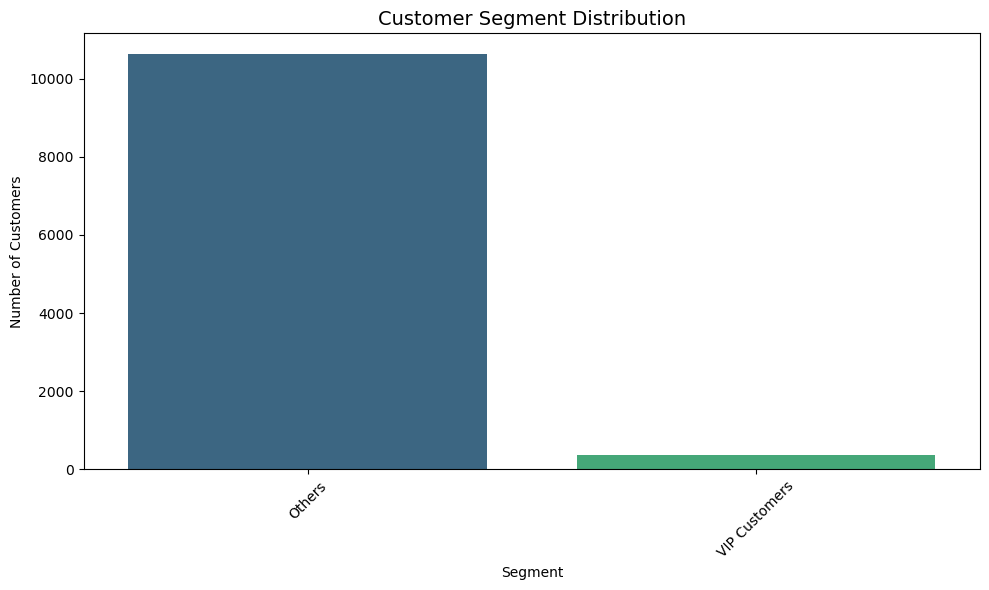

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='viridis')
plt.title("Customer Segment Distribution", fontsize=14)
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [13]:
# RFM skorlarını birleştir
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str)

# Segment kuralları (daha detaylı)
segment_map = {
    r'[5][5]': 'VIP Customers',
    r'[4-5][3-5]': 'Loyal Customers',
    r'[3-4][4-5]': 'Potential Loyalists',
    r'[5][1-2]': 'New Customers',
    r'[3-4][1-3]': 'Needs Attention',
    r'[1-2][4-5]': 'At Risk',
    r'[1-2][1-2]': 'Hibernating'
}

# Regex ile eşleştirerek segment ata
import re

def get_segment(score):
    for pattern, segment in segment_map.items():
        if re.match(pattern, score):
            return segment
    return 'Others'

rfm['Segment'] = rfm['RFM_Score'].apply(get_segment)


C:\Users\zehra\AppData\Local\Temp\ipykernel_3112\3852615847.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='cubehelix')


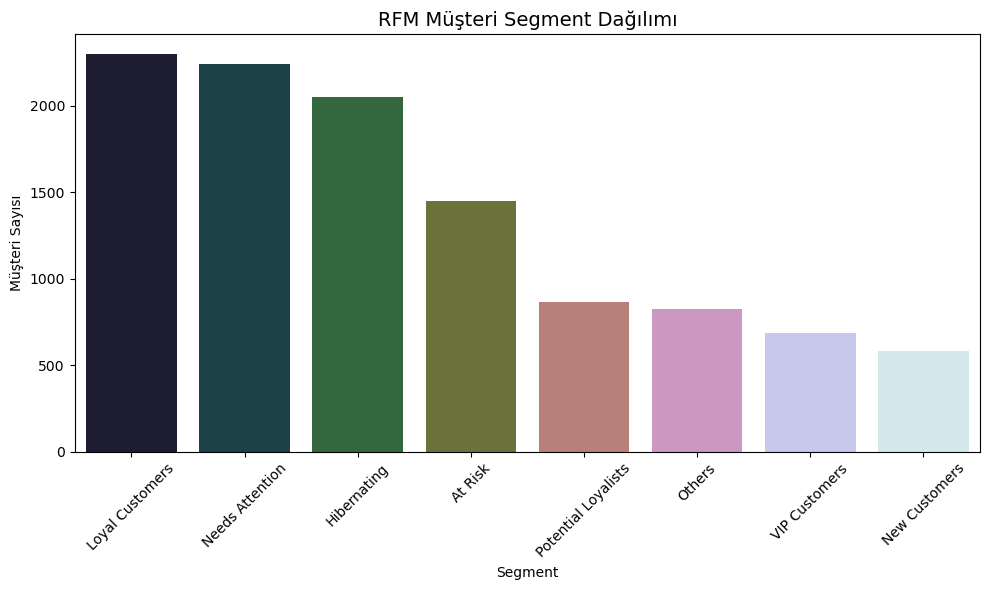

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='cubehelix')
plt.title("RFM Müşteri Segment Dağılımı", fontsize=14)
plt.xlabel("Segment")
plt.ylabel("Müşteri Sayısı")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\zehra\AppData\Local\Temp\ipykernel_3112\694044206.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_monetary.index, y=segment_monetary.values, palette='Blues_d')


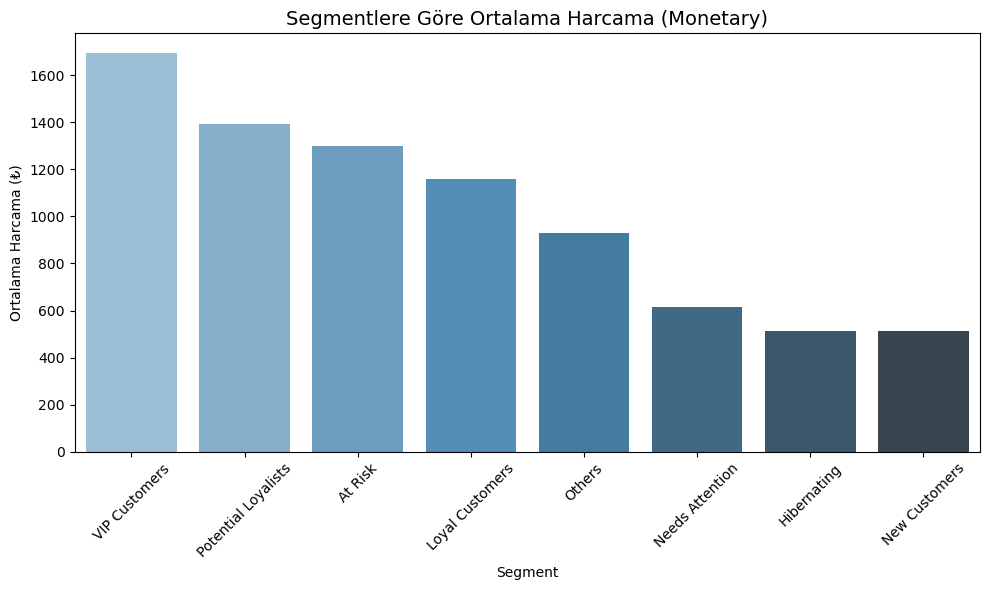

In [15]:
plt.figure(figsize=(10, 6))
segment_monetary = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
sns.barplot(x=segment_monetary.index, y=segment_monetary.values, palette='Blues_d')
plt.title("Segmentlere Göre Ortalama Harcama (Monetary)", fontsize=14)
plt.xlabel("Segment")
plt.ylabel("Ortalama Harcama (₺)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import seaborn as sns
import matplotlib.pyplot as plt


In [17]:
# Eğer rfm tablosu yoksa önce onu oluştur
# Burada Recency, Frequency, Monetary zaten hesaplanmış olmalı

# Ölçekleme işlemi (DBSCAN mesafeye duyarlıdır!)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])


In [18]:
# DBSCAN modeli
db = DBSCAN(eps=0.8, min_samples=5)
rfm['DBSCAN_Cluster'] = db.fit_predict(rfm_scaled)


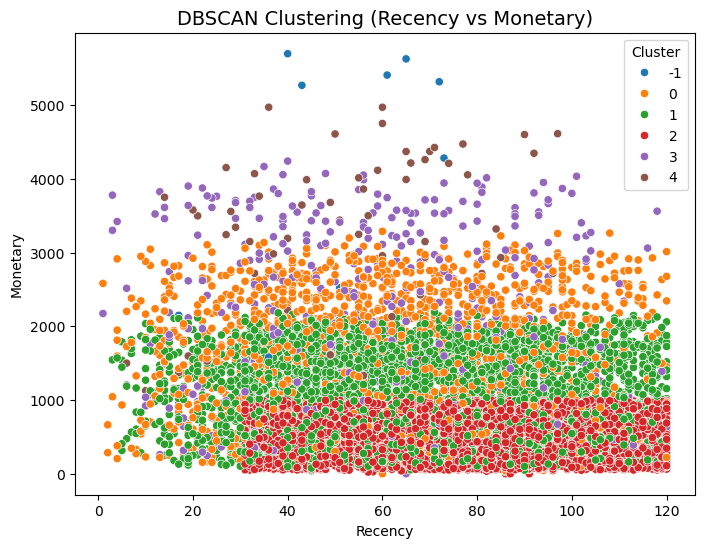

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='DBSCAN_Cluster', palette='tab10')
plt.title('DBSCAN Clustering (Recency vs Monetary)', fontsize=14)
plt.legend(title='Cluster')
plt.show()


In [20]:
rfm['DBSCAN_Cluster'].value_counts()


DBSCAN_Cluster
 2    4826
 1    3993
 0    1633
 3     458
 4      75
-1      14
Name: count, dtype: int64

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [23]:
df = pd.read_excel("C:\\Users\zehra\OneDrive\\Masaüstü\dataset2025.xlsx")
df['OrderDate'] = pd.to_datetime(df['PurchaseDate'])  # Tarih sütunu

# En son alışveriş tarihi varsayılan olarak en güncel tarih alınır
snapshot_date = df['PurchaseDate'].max() + pd.Timedelta(days=1)

# RFM hesaplama
rfm = df.groupby('CustomerID').agg({
    'OrderDate': lambda x: (snapshot_date - x.max()).days,   # Recency
    'OrderID': 'nunique',                                     # Frequency
    'PurchaseAmount': 'sum'                                   # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']


In [24]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])


C:\Users\zehra\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Sistem belirtilen dosyayı bulamıyor
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\zehra\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\zehra\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\zehra\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^

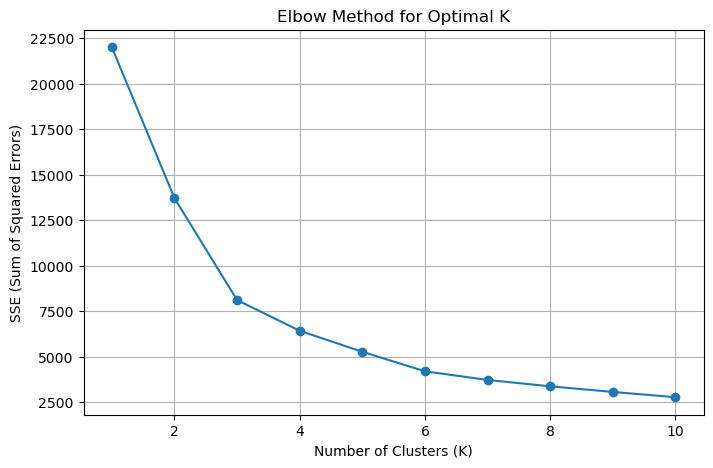

In [25]:
sse = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, sse, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSE (Sum of Squared Errors)")
plt.title("Elbow Method for Optimal K")
plt.grid(True)
plt.show()


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster


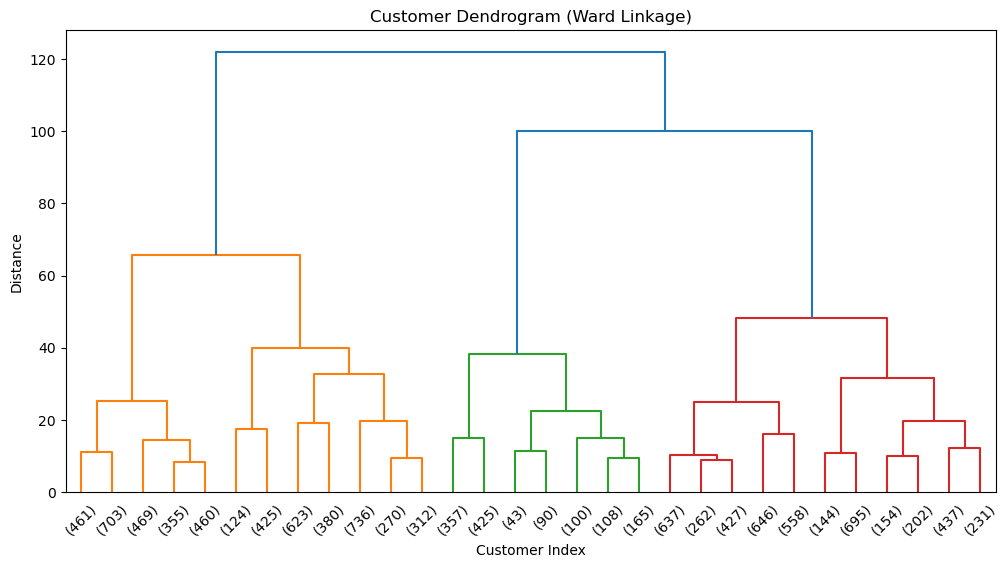

In [28]:
plt.figure(figsize=(12, 6))
linkage_matrix = linkage(rfm_scaled, method='ward')
dendrogram(linkage_matrix, truncate_mode='lastp', p=30)
plt.title('Customer Dendrogram (Ward Linkage)')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.show()


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


In [43]:
# Örnek olarak 'PurchaseDate' kolonu olduğunu varsayıyoruz
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])


In [44]:
# Her müşteri için en son alışveriş tarihi
last_purchase = df.groupby('CustomerID')['PurchaseDate'].max().reset_index()
last_purchase.columns = ['CustomerID', 'LastPurchaseDate']


In [45]:
# Bugünün tarihini manuel olarak belirle (veri setine göre örnek: 1 Temmuz 2025)
today = pd.to_datetime('2025-07-01')

# Recency (Son alışverişten bu yana geçen gün sayısı)
last_purchase['Recency'] = (today - last_purchase['LastPurchaseDate']).dt.days


In [46]:
# Recency > 60 gün olanları churn olarak kabul edelim
last_purchase['ChurnStatus'] = last_purchase['Recency'].apply(lambda x: 'Churn' if x > 60 else 'Active')


C:\Users\zehra\AppData\Local\Temp\ipykernel_3112\2590337795.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=last_purchase, x='ChurnStatus', palette='Set2')


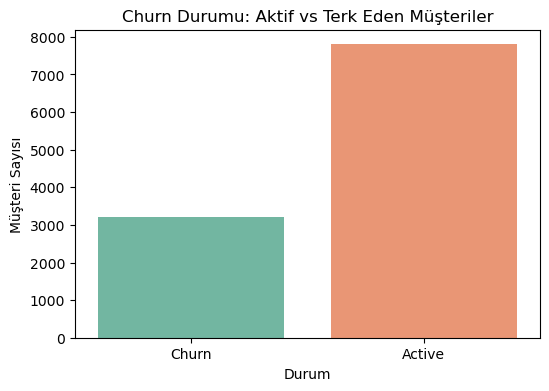

In [47]:
# Churn vs Active oran grafiği
plt.figure(figsize=(6, 4))
sns.countplot(data=last_purchase, x='ChurnStatus', palette='Set2')
plt.title('Churn Durumu: Aktif vs Terk Eden Müşteriler')
plt.xlabel('Durum')
plt.ylabel('Müşteri Sayısı')
plt.show()


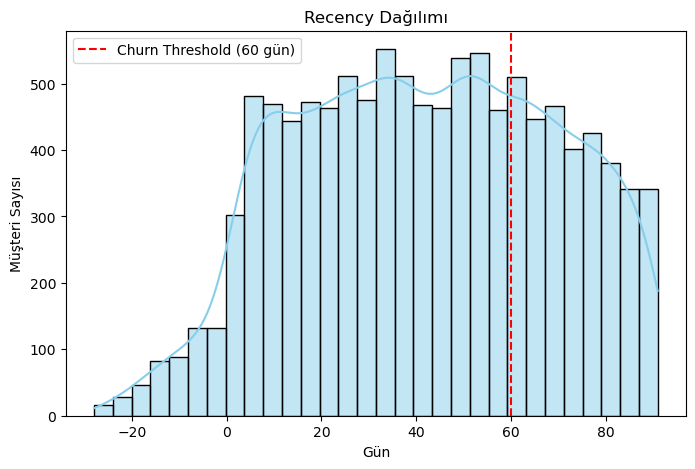

In [48]:
plt.figure(figsize=(8, 5))
sns.histplot(data=last_purchase, x='Recency', bins=30, kde=True, color='skyblue')
plt.axvline(60, color='red', linestyle='--', label='Churn Threshold (60 gün)')
plt.title('Recency Dağılımı')
plt.xlabel('Gün')
plt.ylabel('Müşteri Sayısı')
plt.legend()
plt.show()


In [49]:
# Tarih kolonu datetime formatına çevrilmeli
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])


In [50]:
# Müşteri bazında temel istatistikler
clv_df = df.groupby('CustomerID').agg({
    'PurchaseAmount': ['sum', 'count'],
    'PurchaseDate': ['min', 'max']
}).reset_index()

# Kolon isimlerini sadeleştir
clv_df.columns = ['CustomerID', 'TotalRevenue', 'TotalTransactions', 'FirstPurchaseDate', 'LastPurchaseDate']


In [51]:
clv_df['AverageOrderValue'] = clv_df['TotalRevenue'] / clv_df['TotalTransactions']


In [52]:
clv_df['CustomerLifespan'] = (clv_df['LastPurchaseDate'] - clv_df['FirstPurchaseDate']).dt.days + 1


In [53]:
clv_df['PurchaseFrequency'] = clv_df['TotalTransactions'] / clv_df['CustomerLifespan']


In [54]:
clv_df['CLV'] = clv_df['AverageOrderValue'] * clv_df['PurchaseFrequency'] * clv_df['CustomerLifespan']


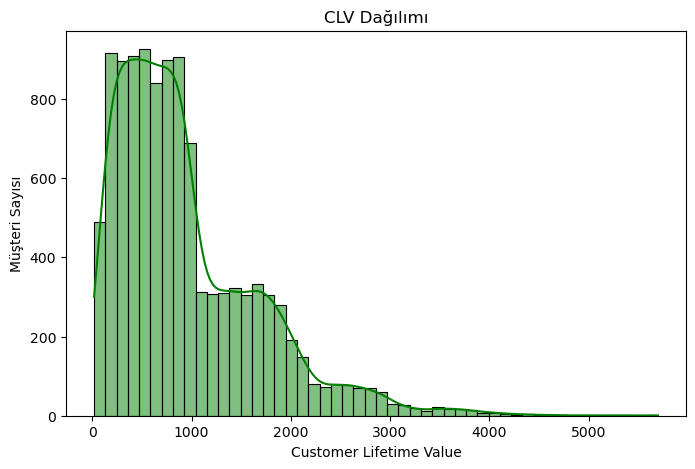

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(clv_df['CLV'], bins=50, kde=True, color='green')
plt.title('CLV Dağılımı')
plt.xlabel('Customer Lifetime Value')
plt.ylabel('Müşteri Sayısı')
plt.show()


In [56]:
top_customers = clv_df.sort_values(by='CLV', ascending=False).head(10)
print(top_customers[['CustomerID', 'CLV']])


       CustomerID      CLV
6103     60392566  5696.77
5148     52670749  5626.95
8114     76576487  5407.22
10160    93390743  5316.35
1619     23656579  5268.49
1126     19465193  4971.08
4063     43467275  4970.97
1343     21416377  4751.27
1533     22903414  4611.91
8339     78528572  4608.49


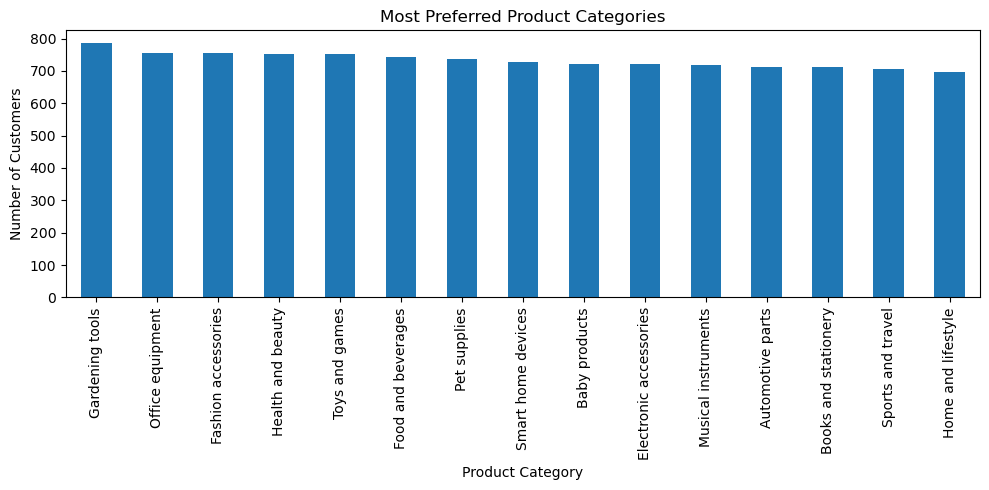

In [57]:
# En çok harcama yapılan ürün kategorisini bul
top_category = df.groupby(['CustomerID', 'ProductCategory'])['PurchaseAmount'].sum().reset_index()

# Her müşteri için en çok harcadığı kategori
top_category = top_category.sort_values(['CustomerID', 'PurchaseAmount'], ascending=[True, False])
top_category = top_category.drop_duplicates('CustomerID')

# Ürün bazlı segment adı ver
top_category.rename(columns={'ProductCategory': 'PreferredCategory'}, inplace=True)

# RFM tablosuyla birleştir
rfm_product = rfm.merge(top_category[['CustomerID', 'PreferredCategory']], on='CustomerID', how='left')

# Kontrol edelim
rfm_product['PreferredCategory'].value_counts().plot(kind='bar', figsize=(10,5), title='Most Preferred Product Categories')
plt.xlabel("Product Category")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


C:\Users\zehra\AppData\Local\Temp\ipykernel_3112\492006625.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_trend, x='OrderMonth', y='PurchaseAmount', palette='coolwarm')


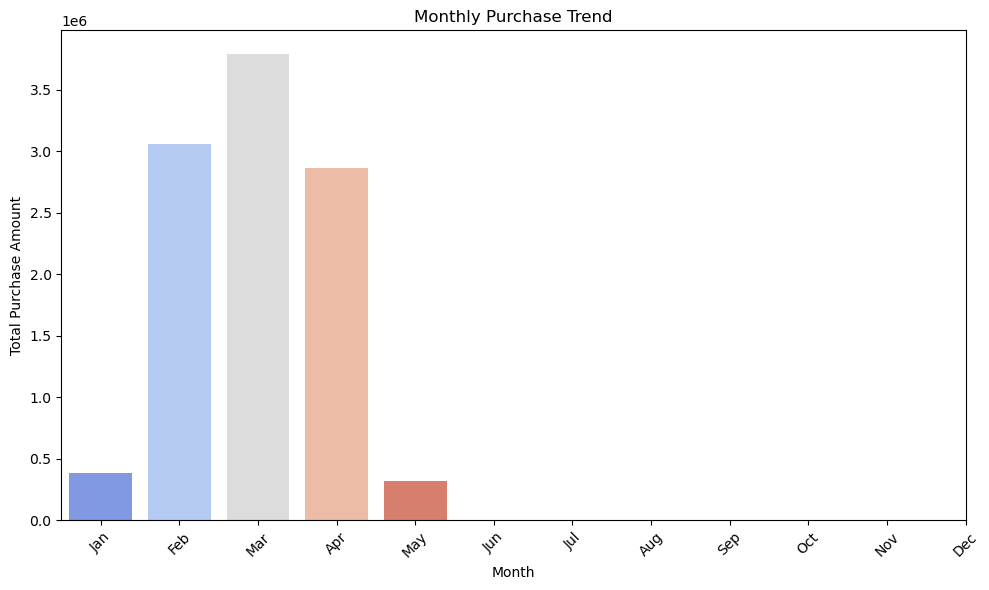

In [58]:
# Sipariş tarihini datetime'a çevir
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Ay bilgisini çıkar
df['OrderMonth'] = df['OrderDate'].dt.month

# Ay bazında toplam harcamaları incele
monthly_trend = df.groupby('OrderMonth')['PurchaseAmount'].sum().reset_index()

# Görselleştir
plt.figure(figsize=(10,6))
sns.barplot(data=monthly_trend, x='OrderMonth', y='PurchaseAmount', palette='coolwarm')
plt.title('Monthly Purchase Trend')
plt.xlabel('Month')
plt.ylabel('Total Purchase Amount')
plt.xticks(range(0, 12), [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
], rotation=45)
plt.tight_layout()
plt.show()
